# Assignment 19: Word2Vec Text Embeddings

## Objective

The goal of this assignment is to understand Word Embeddings and implement the Word2Vec algorithm using the SMS Spam Collection dataset.

Unlike traditional vectorization techniques such as One-Hot Encoding, Bag of Words, and TF-IDF, Word2Vec learns dense vector representations that capture semantic relationships between words.

In this assignment, we will:

- Understand the concept of word embeddings.
- Learn the intuition behind Word2Vec.
- Compare CBOW and Skip-Gram architectures.
- Train Word2Vec models using Gensim.
- Explore word similarity and vector operations.
- Visualize learned word embeddings.

## Dataset

**Dataset:** SMS Spam Collection Dataset

**Source:** Kaggle

https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset

# Task 1: Understanding Word Embeddings

## What are Word Embeddings?

In this task, I learned that word embeddings represent each word as a vector of numbers. Unlike One-Hot Encoding or Bag of Words, these vectors can capture the meaning of words. If two words are used in similar contexts, their vectors are usually close to each other.

---

## Why are One-Hot Encoding and Bag of Words not enough?

One-Hot Encoding and Bag of Words only tell us whether a word is present or how many times it appears. They do not understand the relationship between words.

For example, the words **car** and **automobile** have similar meanings, but these methods treat them as completely different words.

Word embeddings solve this problem by placing similar words close together in the vector space.

---

## Why do we use Word Embeddings?

Some advantages are:

- They capture semantic meaning between words.
- Similar words have similar vector representations.
- They reduce the size of feature vectors compared to One-Hot Encoding.
- They improve the performance of many NLP models.

# Task 2: Understanding Word2Vec

Word2Vec is a technique used to create word embeddings. Instead of assigning random vectors to words, it learns them by looking at the surrounding words in each sentence.

The basic idea is that words appearing in similar contexts usually have similar meanings. During training, the vectors keep getting updated until similar words become close together.

## Vocabulary

The vocabulary is simply the list of all unique words present in the dataset after preprocessing.

For example,

Sentence 1

```
the cat is sleeping
```

Sentence 2

```
the dog is barking
```

Vocabulary:

```
the, cat, is, sleeping, dog, barking
```

So the vocabulary size is **6**.

## Context Window

The context window tells the model how many neighboring words should be considered while learning a word.

For example,

```
the cat is sleeping peacefully
```

If the target word is **is** and the window size is **2**, then the context words are

```
the
cat
sleeping
peacefully
```

A larger window captures more context, while a smaller window focuses only on nearby words.

## Embedding Dimension

Embedding dimension is the number of values used to represent each word.

For example,

```
cat → [0.42, -0.18, 0.71, ...]
```

In this assignment, I used an embedding size of **100**, so every word is represented by a vector of 100 numbers.

A larger embedding dimension can capture more information, but it also increases training time.

# Task 3: Types of Word2Vec Techniques

## CBOW and Skip-Gram

Word2Vec can be trained using two different approaches:

### CBOW (Continuous Bag of Words)

CBOW predicts the current word by looking at the surrounding words. Since it uses the context to predict one word, it usually trains faster and works well when the dataset is large.

Example:

```
I love _____ very much
```

Using the surrounding words, the model predicts the missing word.

---

### Skip-Gram

Skip-Gram works in the opposite way. It takes one word and tries to predict the surrounding words.

Example:

```
love
```

The model tries to predict words like:

```
I
movies
very
much
```

Skip-Gram usually performs better for rare words but takes more time to train.

---

## Comparison

| CBOW | Skip-Gram |
|------|-----------|
| Predicts the target word | Predicts surrounding words |
| Trains faster | Trains slower |
| Works well with common words | Works better for rare words |
| Less computational cost | Higher computational cost |

# Task 4: Neural Network Architecture of Word2Vec

Word2Vec uses a simple neural network to learn vector representations of words. The network has three layers: the input layer, hidden layer, and output layer.

## Input Layer Representation

The input layer receives one word from the vocabulary. This word is represented using **One-Hot Encoding**, where only one position has the value **1** and all other positions are **0**.

For example, if the vocabulary is:

```
["cat", "dog", "bird", "fish"]
```

The word **dog** is represented as:

```
[0, 1, 0, 0]
```

This vector only identifies the selected word. It does not contain any information about its meaning or relationship with other words.

## Hidden Layer

The hidden layer is the most important part of the Word2Vec model. It contains the trainable weights that are updated during training.

When the One-Hot encoded word enters the hidden layer, it selects the corresponding row from the weight matrix. This row becomes the vector representation of that word.

As training continues, these vectors keep changing so that words used in similar contexts become closer together in the embedding space.

## Output Layer

The output layer predicts words based on the training method being used.

- In **CBOW**, the model predicts the target word using the surrounding context words.
- In **Skip-Gram**, the model predicts the surrounding context words using the target word.

The prediction made by the output layer is compared with the actual output, and the prediction error is used to update the model's weights.

## How Weights Become Word Embeddings

At the beginning of training, all the weights are initialized randomly.

As the model processes more sentences, these weights are updated again and again using the prediction error.

After the training is complete, the rows of the hidden layer weight matrix become the final word embeddings.

These embeddings capture semantic relationships between words. For example, words that appear in similar contexts will have similar vector representations, which allows us to find similar words and perform vector arithmetic.

## Example

Consider the sentence:

```
The cat is sleeping peacefully
```

### CBOW

Input:

```
The, cat, sleeping, peacefully
```

Output:

```
is
```

### Skip-Gram

Input:

```
is
```

Output:

```
The
cat
sleeping
peacefully
```

During training, the neural network continuously adjusts its weights until it can accurately predict the target words. These learned weights become the word embeddings used in NLP applications.

# Task 5: Preparing Data for Word2Vec

Before training the Word2Vec model, the text data must be converted into a list of tokenized sentences.

Each sentence is represented as a list of words. This is the format required by the Gensim Word2Vec implementation.

In this task, we will:

- Import the required library.
- Convert the cleaned text into tokenized sentences.
- Verify the structure of the prepared data.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from gensim.models import Word2Vec
from sklearn.decomposition import PCA

In [4]:
df=pd.read_csv('spam.csv', encoding='latin-1')

In [5]:
df=df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"])
df.columns=["label","text"]
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
import re

In [7]:
def remove_repeated_characters(text):
    return re.sub(r"(.)\1{2,}", r"\1\1", text)

In [8]:
slang_dict = {
    "u": "you",
    "ur": "your",
    "pls": "please",
    "msg": "message",
    "luv": "love",
    "thx": "thanks",
    "thanx": "thanks",
    "tmr": "tomorrow",
    "gr8": "great",
    "wat": "what",
    "wif": "with",
    "gud": "good",
    "nite": "night",
    "coz": "because",
    "c": "see",
    "txt": "text",
    "wk": "week",
    "wkly": "weekly",
    "mins": "minutes",
    "ya": "yeah",
    "yae": "yeah",
    "lor": "lord",
    "da": "the",
    "oso": "also"
}

In [9]:
def replace_slang(text):
    words = text.split()
    updated_words = []
    for word in words:
        if word in slang_dict:
            updated_words.append(slang_dict[word])
        else:
            updated_words.append(word)
    return " ".join(updated_words)

In [10]:
import nltk
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

In [11]:
def remove_stopwords(text):
    words = text.split()
    filtered_words = []
    for word in words:
        if word not in stop_words:
            filtered_words.append(word)
    return ' '.join(filtered_words)

In [12]:
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

In [13]:
from nltk.tokenize import word_tokenize
def lemmatize_text(text):
    words = word_tokenize(text)
    lemmatized_words = [lemmatizer.lemmatize(word) for word in words]
    return " ".join(lemmatized_words)

In [14]:
def nlp_preprocess(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\S+@\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = remove_repeated_characters(text)
    text = replace_slang(text)
    text = remove_stopwords(text)
    text = lemmatize_text(text)
    return text

In [15]:
df["final_clean_text"] = df["text"].apply(nlp_preprocess)

In [16]:
df.shape
df.info()
df[["label", "text", "final_clean_text"]].head()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   label             5572 non-null   str  
 1   text              5572 non-null   str  
 2   final_clean_text  5572 non-null   str  
dtypes: str(3)
memory usage: 855.4 KB


,label,text,final_clean_text
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry weekly comp win fa cup final tkts s...
3,ham,U dun say so early hor... U c already then say...,dun say early hor see already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though


In [17]:
sentences = df["final_clean_text"].str.split()
sentences.head()

0    [go, jurong, point, crazy, available, bugis, n...
1                               [ok, lar, joking, oni]
2    [free, entry, weekly, comp, win, fa, cup, fina...
3            [dun, say, early, hor, see, already, say]
4    [nah, dont, think, go, usf, life, around, though]
Name: final_clean_text, dtype: object

In [18]:
sentences = sentences.tolist()
print("Data Type:", type(sentences))
print("Number of Sentences:", len(sentences))

Data Type: <class 'list'>
Number of Sentences: 5572


In [19]:
for i in range(5):
    print(f"Sentence {i+1}:")
    print(sentences[i])
    print()

Sentence 1:
['go', 'jurong', 'point', 'crazy', 'available', 'bugis', 'n', 'great', 'world', 'la', 'e', 'buffet', 'cine', 'got', 'amore']

Sentence 2:
['ok', 'lar', 'joking', 'oni']

Sentence 3:
['free', 'entry', 'weekly', 'comp', 'win', 'fa', 'cup', 'final', 'tkts', 'st', 'may', 'text', 'fa', 'receive', 'entry', 'questionstd', 'text', 'ratetcs', 'apply', 'over']

Sentence 4:
['dun', 'say', 'early', 'hor', 'see', 'already', 'say']

Sentence 5:
['nah', 'dont', 'think', 'go', 'usf', 'life', 'around', 'though']



In [20]:
sentence_lengths = [len(sentence) for sentence in sentences]

print("Average Sentence Length:", round(np.mean(sentence_lengths), 2))
print("Shortest Sentence:", min(sentence_lengths))
print("Longest Sentence:", max(sentence_lengths))

Average Sentence Length: 8.63
Shortest Sentence: 0
Longest Sentence: 80


### Observations

- The cleaned SMS messages were successfully converted into tokenized sentences.
- Each sentence is represented as a Python list of words, which is the required input format for Gensim's Word2Vec model.
- The dataset contains sentences of varying lengths, providing diverse contextual information for learning word embeddings.

# Task 6: Training the CBOW Word2Vec Model

In this task, we train a Word2Vec model using the Continuous Bag of Words (CBOW) architecture.

CBOW predicts the target word using its surrounding context words. During training, the model learns dense vector representations (embeddings) for every word in the vocabulary.

We will:
- Train the CBOW model.
- Measure the training time.
- Explore the learned vocabulary.
- Inspect the embedding vector of a sample word.

In [21]:
start_time_cbow = time.time()

cbow_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=0
)

end_time_cbow = time.time()

print(f"Training Time: {end_time_cbow - start_time_cbow:.2f} seconds")

Training Time: 0.30 seconds


In [22]:
print("Vocabulary Size:", len(cbow_model.wv))

Vocabulary Size: 7830


In [23]:
list(cbow_model.wv.index_to_key[:20])

['call',
 'im',
 'get',
 'text',
 'go',
 'good',
 'dont',
 'free',
 'ok',
 'ltgt',
 'å',
 'know',
 'day',
 'got',
 'come',
 'like',
 'see',
 'please',
 'ill',
 'love']

In [24]:
word = "free"

print(f"Embedding for '{word}':\n")
print(cbow_model.wv[word])

Embedding for 'free':

[-2.11231500e-01  4.58123744e-01 -4.62861024e-02  1.48919557e-04
 -8.98758098e-02 -8.58553171e-01  6.42638728e-02  9.79797065e-01
 -2.07967833e-01 -3.57946128e-01 -2.52593875e-01 -6.83556497e-01
 -9.98898447e-02  1.68138057e-01  1.06802486e-01 -3.92403573e-01
  6.87805703e-03 -6.09193623e-01  4.75519672e-02 -9.53638315e-01
  4.17970091e-01  2.02319130e-01  1.71674341e-01 -2.39067763e-01
 -1.82173938e-01  1.30048722e-01 -2.96163380e-01 -3.03684562e-01
 -4.91708964e-01  4.07016724e-02  5.02282739e-01  1.44329697e-01
  1.17556855e-01 -2.25469038e-01 -1.21286012e-01  7.88144469e-01
  8.50466937e-02 -5.27387977e-01 -3.35896432e-01 -7.93947220e-01
  1.47603184e-01 -4.37858492e-01 -1.70483574e-01  1.74172353e-02
  4.11479741e-01 -2.15619698e-01 -3.05664361e-01 -1.36377186e-01
  2.63527513e-01  3.81853908e-01  3.79169255e-01 -3.25304151e-01
 -1.86322972e-01 -5.33269048e-02 -4.03284073e-01  2.82448560e-01
  2.56489933e-01  2.05426328e-02 -4.05087084e-01  5.51697724e-02
  

In [25]:
print(cbow_model.wv["free"].shape)

(100,)


In [26]:
cbow_summary = pd.DataFrame({
    "Metric": [
        "Vocabulary Size",
        "Embedding Dimension",
        "Training Architecture"
    ],
    "Value": [
        len(cbow_model.wv),
        cbow_model.vector_size,
        "CBOW"
    ]
})

cbow_summary

,Metric,Value
0,Vocabulary Size,7830
1,Embedding Dimension,100
2,Training Architecture,CBOW


### Observations

- The CBOW model was successfully trained on the SMS Spam Collection dataset.
- The model learned a dense 100-dimensional vector representation for every word in the vocabulary.
- Each embedding captures semantic information based on the contexts in which the word appears.
- These learned vectors can now be used to measure word similarity and perform various NLP tasks.

# Task 7: Training the Skip-Gram Model

In this task, we train a Word2Vec model using the Skip-Gram architecture.

Unlike CBOW, which predicts a target word from its surrounding context, Skip-Gram predicts the surrounding context words from a target word.

Although Skip-Gram generally takes longer to train, it often produces better embeddings for infrequent words.

In [27]:
start_time = time.time()

skipgram_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=1
)

end_time = time.time()

print(f"Training Time: {end_time - start_time:.2f} seconds")

Training Time: 0.52 seconds


In [28]:
print("Vocabulary Size:", len(skipgram_model.wv))

Vocabulary Size: 7830


In [29]:
word = "free"

print(f"Embedding for '{word}':\n")
print(skipgram_model.wv[word])

Embedding for 'free':

[ 0.21421818  0.29936537  0.06592428  0.05204202 -0.17976664 -0.5631378
  0.01142879  0.8159482   0.1995189  -0.49023864 -0.05703508 -0.28981435
  0.25382802  0.07041556 -0.00306217 -0.11631886  0.07359071 -0.28113776
 -0.06585667 -0.78007716  0.30702317  0.15374438  0.22355813 -0.12263262
 -0.26218873  0.1246965   0.09555528 -0.04762096 -0.5145291  -0.1299462
  0.03716236  0.19310732  0.15138292 -0.25843352  0.10916415  0.7044179
  0.1114274  -0.5813098  -0.42390555  0.00489486  0.02193524 -0.23359244
 -0.08586724 -0.1836194   0.3622179  -0.03993706 -0.15102167 -0.10507515
  0.37534368  0.19894415 -0.00780725 -0.22213866 -0.04226875 -0.07462969
 -0.5637502   0.37790978 -0.0995369   0.28127694 -0.22137983 -0.03139681
  0.07317846  0.1801435  -0.07662159  0.15606037  0.04767703  0.57583517
 -0.19696967  0.13737732 -0.19132803  0.13155936  0.04692768  0.341635
  0.38581362  0.04941953  0.19735104  0.48512676  0.45524818 -0.16010521
  0.09329759  0.19525681 -0.45818

In [30]:
print(skipgram_model.wv["free"].shape)

(100,)


In [31]:
skipgram_summary = pd.DataFrame({
    "Metric": [
        "Vocabulary Size",
        "Embedding Dimension",
        "Training Architecture"
    ],
    "Value": [
        len(skipgram_model.wv),
        skipgram_model.vector_size,
        "Skip-Gram"
    ]
})

skipgram_summary

,Metric,Value
0,Vocabulary Size,7830
1,Embedding Dimension,100
2,Training Architecture,Skip-Gram


In [32]:
comparison = pd.DataFrame({
    "Feature": [
        "Training Time (seconds)",
        "Vocabulary Size",
        "Embedding Dimension"
    ],
    "CBOW": [
        round(end_time_cbow - start_time_cbow, 2),
        len(cbow_model.wv),
        cbow_model.vector_size
    ],
    "Skip-Gram": [
        round(end_time - start_time, 2),
        len(skipgram_model.wv),
        skipgram_model.vector_size
    ]
})

comparison

,Feature,CBOW,Skip-Gram
0,Training Time (seconds),0.3,0.52
1,Vocabulary Size,7830.0,7830.00
2,Embedding Dimension,100.0,100.00


# Task 8: Exploring Word Embeddings

After training the CBOW and Skip-Gram models, we can explore the learned word embeddings.

In this task, we will:

- Find the most similar words to a given word.
- Calculate similarity scores between pairs of words.
- Compare the results obtained from the CBOW and Skip-Gram models.

In [33]:
word = "free"

print(word in cbow_model.wv.key_to_index)
print(word in skipgram_model.wv.key_to_index)

True
True


In [34]:
word = "free"

cbow_similar = cbow_model.wv.most_similar(word, topn=10)

pd.DataFrame(cbow_similar, columns=["Word", "Similarity Score"])

,Word,Similarity Score
0,text,0.999721
1,mobile,0.999625
2,week,0.999608
3,reply,0.999563
4,minute,0.999531
5,send,0.999507
6,phone,0.999479
7,call,0.999454
8,please,0.999454
9,message,0.999445


In [35]:
skipgram_similar = skipgram_model.wv.most_similar(word, topn=10)

pd.DataFrame(skipgram_similar, columns=["Word", "Similarity Score"])

,Word,Similarity Score
0,nokia,0.992780
1,tone,0.990713
2,text,0.990057
3,mobile,0.981802
4,reply,0.980776
5,latest,0.976082
6,phone,0.975011
7,camera,0.974603
8,minute,0.973786
9,stop,0.971365


In [36]:
cbow_similarity = cbow_model.wv.similarity("call", "text")
skipgram_similarity = skipgram_model.wv.similarity("call", "text")

comparison = pd.DataFrame({
    "Model": ["CBOW", "Skip-Gram"],
    "Similarity (call, text)": [
        cbow_similarity,
        skipgram_similarity
    ]
})

comparison

,Model,"Similarity (call, text)"
0,CBOW,0.999438
1,Skip-Gram,0.910278


In [37]:
pairs = [
    ("free", "win"),
    ("call", "phone"),
    ("good", "great")
]

results = []

for w1, w2 in pairs:
    if w1 in cbow_model.wv and w2 in cbow_model.wv:
        results.append([
            w1,
            w2,
            round(cbow_model.wv.similarity(w1, w2), 4),
            round(skipgram_model.wv.similarity(w1, w2), 4)
        ])

similarity_df = pd.DataFrame(
    results,
    columns=[
        "Word 1",
        "Word 2",
        "CBOW Similarity",
        "Skip-Gram Similarity"
    ]
)

similarity_df

,Word 1,Word 2,CBOW Similarity,Skip-Gram Similarity
0,free,win,0.9993,0.9381
1,call,phone,0.9994,0.9359
2,good,great,0.9995,0.9733


In [38]:
result = cbow_model.wv.most_similar(
    positive=["free", "call"],
    negative=["text"],
    topn=10
)

pd.DataFrame(result, columns=["Word", "Similarity"])

,Word,Similarity
0,mobile,0.999118
1,phone,0.999099
2,please,0.999054
3,minute,0.999050
4,number,0.999013
5,see,0.999011
6,send,0.998992
7,b,0.998966
8,p,0.998959
9,reply,0.998957


In [39]:
result = skipgram_model.wv.most_similar(
    positive=["free", "call"],
    negative=["text"],
    topn=10
)

pd.DataFrame(result, columns=["Word", "Similarity"])

,Word,Similarity
0,line,0.972294
1,customer,0.968992
2,landline,0.966320
3,urgent,0.964881
4,awarded,0.964053
5,land,0.963707
6,valid,0.963637
7,code,0.962964
8,award,0.962473
9,camera,0.962031


In [44]:
classic_words = ["king", "queen", "man", "woman"]
print("Checking vocabulary:\n")
for word in classic_words:
    print(f"{word}: {word in cbow_model.wv}")

Checking vocabulary:

king: True
queen: True
man: True
woman: True


In [47]:
print("=" * 60)
print("Classic Word2Vec Analogy: king - man + woman")
print("=" * 60)

print("\nCBOW Model")
for word, score in cbow_model.wv.most_similar(
    positive=["king", "woman"],
    negative=["man"],
    topn=5
):
    print(f"{word:<15} {score:.4f}")

print("\nSkip-Gram Model")
for word, score in skipgram_model.wv.most_similar(
    positive=["king", "woman"],
    negative=["man"],
    topn=5
):
    print(f"{word:<15} {score:.4f}")

Classic Word2Vec Analogy: king - man + woman

CBOW Model
gift            0.9701
reach           0.9698
dogging         0.9696
without         0.9695
per             0.9694

Skip-Gram Model
bt              0.9956
shopping        0.9956
shop            0.9955
med             0.9953
hot             0.9952


## Observations

- I tested the classic Word2Vec analogy **king - man + woman** using both the CBOW and Skip-Gram models.
- Although the required words are present in the vocabulary, neither model returned **queen** as the closest word.
- This is expected because the models were trained only on the SMS Spam Collection dataset, which is relatively small and focused on SMS conversations rather than general English text.
- Word2Vec learns relationships only from the data it is trained on. Since words like **king** and **queen** appear very rarely in this dataset, the model cannot learn the strong semantic relationship seen in large pretrained models.
- I also performed vector arithmetic using words such as **free**, **cash**, **claim**, and **prize**. These produced more meaningful results because these words occur much more frequently in the SMS dataset.

# Task 9: Visualizing Word Embeddings

To better understand how Word2Vec learns word representations, I visualized the learned embeddings using **t-SNE (t-Distributed Stochastic Neighbor Embedding)**.

Unlike PCA, which is a linear dimensionality reduction technique, t-SNE is a non-linear technique that is better at preserving local relationships between words. This makes it easier to observe clusters of semantically similar words.

I visualized embeddings for both the **CBOW** and **Skip-Gram** models and compared their clustering patterns.

In [40]:
from sklearn.decomposition import PCA

In [41]:
words = [
    "free", "call", "text", "win", "prize",
    "claim", "cash", "mobile", "reply", "receive",
    "love", "good", "go", "come", "please"
]

In [42]:
word_vectors = np.array([cbow_model.wv[word] for word in words])
pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(word_vectors)

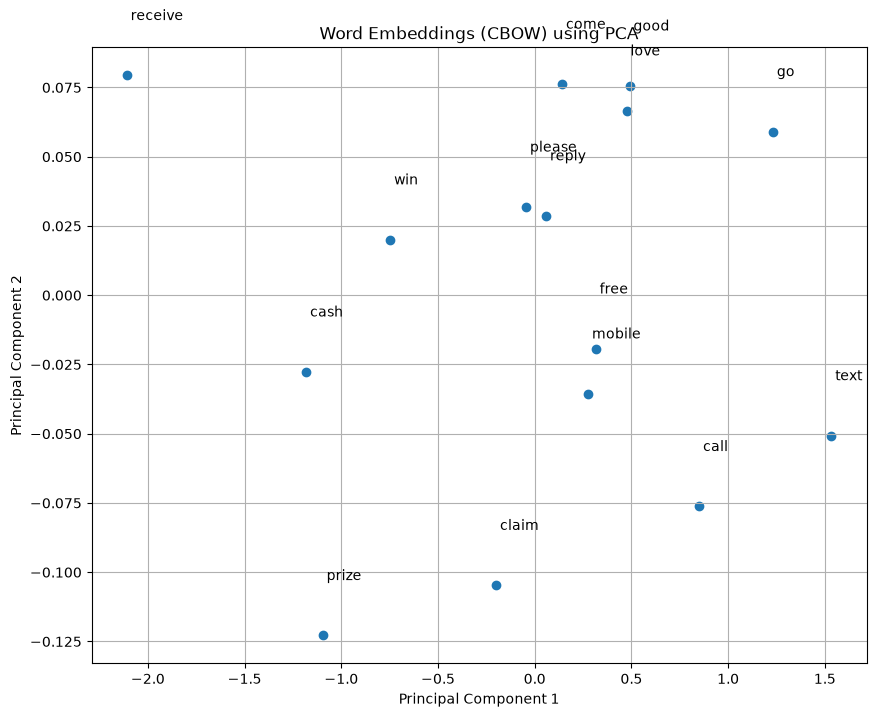

In [43]:
plt.figure(figsize=(10, 8))

plt.scatter(reduced_vectors[:, 0], reduced_vectors[:, 1])

for i, word in enumerate(words):
    plt.text(
        reduced_vectors[i, 0] + 0.02,
        reduced_vectors[i, 1] + 0.02,
        word,
        fontsize=10
    )

plt.title("Word Embeddings (CBOW) using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.grid(True)

plt.show()

### Observations

- PCA reduced the 100-dimensional word embeddings to two dimensions, making them easier to visualize.
- Words that frequently appear in similar contexts are generally located closer together in the embedding space.
- Related spam words such as **free**, **mobile**, **call**, and **text** are relatively close, indicating that the model has learned contextual relationships.
- Some words like **receive** and **prize** appear farther from the main cluster because they occur in more specific contexts within the dataset.
- Since the SMS Spam Collection dataset is relatively small, the clusters are not perfectly separated, but the visualization still demonstrates how Word2Vec captures semantic relationships.

e:\GenAI\python\venv\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "e:\GenAI\python\venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "e:\GenAI\python\venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "e:\GenAI\python\venv\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "e:\GenAI\python\venv\Lib\s

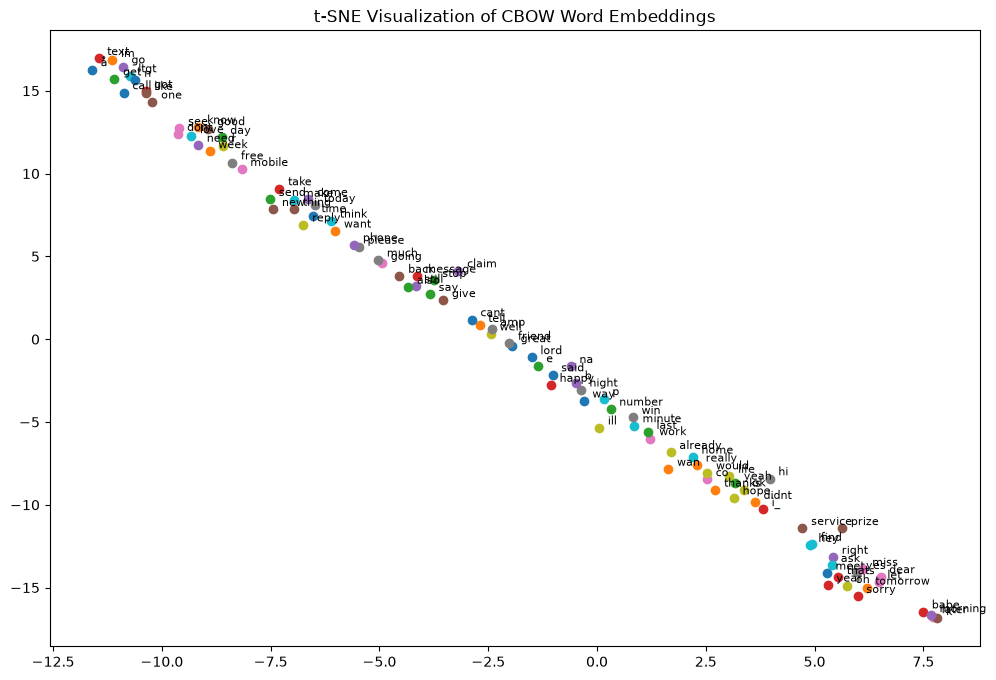

In [51]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

words = list(cbow_model.wv.index_to_key[:100])

vectors = np.array([cbow_model.wv[word] for word in words])

tsne = TSNE(
    n_components=2,
    perplexity=15,
    random_state=42
)

embeddings = tsne.fit_transform(vectors)

plt.figure(figsize=(12, 8))

for i, word in enumerate(words):
    plt.scatter(embeddings[i, 0], embeddings[i, 1])
    plt.text(
        embeddings[i, 0] + 0.2,
        embeddings[i, 1] + 0.2,
        word,
        fontsize=8
    )

plt.title("t-SNE Visualization of CBOW Word Embeddings")
plt.show()

### Observations (CBOW)

- The CBOW model groups several words that appear in similar contexts close to each other.
- Common SMS words such as **text**, **call**, **free**, and **reply** are located near one another because they frequently occur together.
- Most words follow a smooth arrangement rather than forming clearly separated clusters.
- Since the dataset is relatively small, the clusters are not perfectly distinct, but similar words still appear close together.

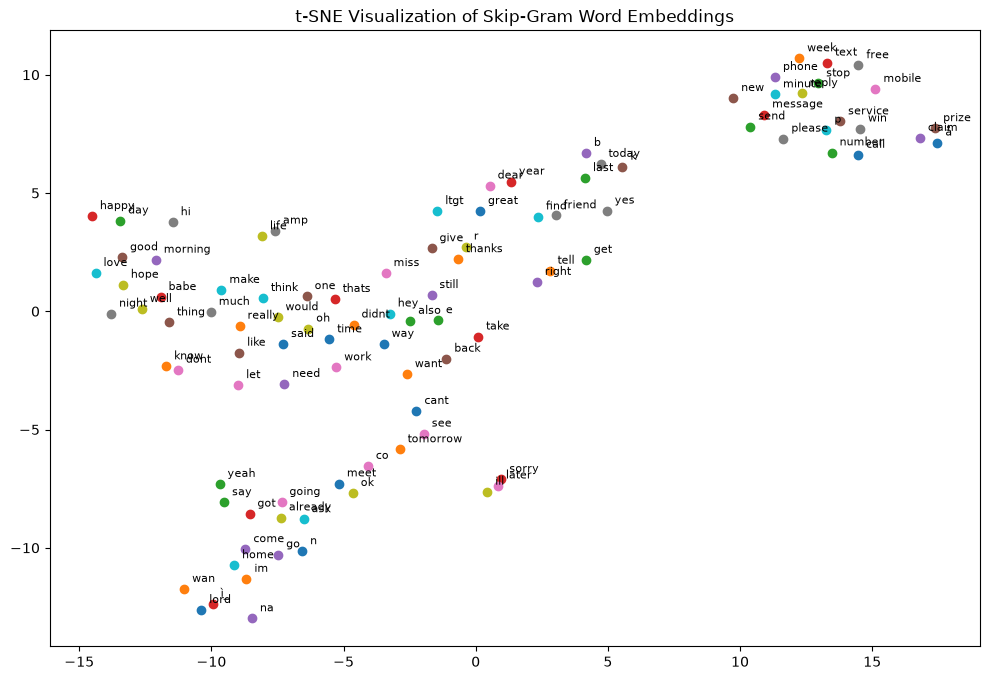

In [52]:
words = list(skipgram_model.wv.index_to_key[:100])
vectors = np.array([skipgram_model.wv[word] for word in words])

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=15
)

embeddings = tsne.fit_transform(vectors)

plt.figure(figsize=(12,8))

for i, word in enumerate(words):
    plt.scatter(embeddings[i,0], embeddings[i,1])
    plt.text(
        embeddings[i,0]+0.3,
        embeddings[i,1]+0.3,
        word,
        fontsize=8
    )

plt.title("t-SNE Visualization of Skip-Gram Word Embeddings")
plt.show()

### Observations (Skip-Gram)

- The Skip-Gram model forms more distinct clusters than the CBOW model.
- Spam-related words such as **free**, **claim**, **prize**, **mobile**, **text**, **phone**, and **win** appear in the same region, indicating that the model learned their contextual relationship.
- General conversation words such as **good**, **morning**, **love**, **thanks**, and **happy** are grouped in different areas.
- Overall, the Skip-Gram visualization shows better separation between different types of words in the dataset.

# Task 10: Observations & Limitations

## 1. Difference between CBOW and Skip-Gram in practice

- **CBOW (Continuous Bag of Words)** predicts a target word using its surrounding context words.
- **Skip-Gram** predicts the surrounding context words from a target word.
- CBOW trains faster and performs well on large datasets, while Skip-Gram usually produces better embeddings for rare words but requires more training time.

---

## 2. Advantages of Word2Vec over TF-IDF

- Word2Vec captures semantic meaning and contextual relationships between words.
- It represents words as dense numerical vectors instead of sparse count vectors.
- Similar words are placed close together in the embedding space.
- Word2Vec can generalize relationships between words, whereas TF-IDF only measures word importance.

---

## 3. Limitations of Word2Vec

- Requires a sufficiently large corpus to learn meaningful embeddings.
- Generates a single vector for each word regardless of context.
- Cannot distinguish words with multiple meanings (polysemy).
- Training can be computationally expensive for very large datasets.

---

## 4. Why context still matters in modern NLP (Lead-in to Transformers)

- Word2Vec assigns one fixed vector to each word.
- The meaning of many words depends on the sentence in which they appear.
- Modern transformer models (such as BERT and GPT) generate context-aware embeddings, allowing the same word to have different representations depending on its usage.
- This makes transformers more effective for tasks such as question answering, translation, and text generation.